# Pneumonia Detection from Chest X-Rays using CNN

This notebook implements a baseline Convolutional Neural Network (CNN) trained from scratch to classify chest X-ray images as either **Normal** or **Pneumonia**.

**Dataset:** [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) by Paul Mooney on Kaggle

**Pipeline:**
1. Setup & Imports
2. Dataset Download
3. Preprocessing & Data Loading
4. Baseline CNN Architecture
5. Training
6. Evaluation & Visualization

---
## 1. Setup & Imports

In [7]:
# Install dependencies if not already present
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "kagglehub"], check=True)

CompletedProcess(args=['c:\\Users\\Brunden\\AppData\\Local\\Programs\\Python\\Python313\\python.exe', '-m', 'pip', 'install', '--quiet', 'kagglehub'], returncode=0)

In [8]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Keras      : {keras.__version__}")

TensorFlow : 2.21.0
NumPy      : 2.2.6
Keras      : 3.14.0


---
## 2. Dataset Download

The dataset is fetched automatically via `kagglehub`. On first run it will download ~1.1 GB to your Kaggle cache. Subsequent runs use the cached copy.

> **Note:** You must have a Kaggle account and your API credentials configured (`~/.kaggle/kaggle.json`). See [Kaggle API docs](https://www.kaggle.com/docs/api) for setup instructions.

In [9]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

100%|██████████| 2.29G/2.29G [00:11<00:00, 219MB/s] 

Extracting files...


Path to dataset files: C:\Users\Brunden\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [10]:
# Locate the chest_xray root (kagglehub may add a versioned subfolder)
data_root = path
for root, dirs, files in os.walk(path):
    if "chest_xray" in dirs:
        data_root = os.path.join(root, "chest_xray")
        break
    if os.path.basename(root) == "chest_xray":
        data_root = root
        break

TRAIN_DIR = os.path.join(data_root, "train")
TEST_DIR  = os.path.join(data_root, "test")

print("Data root  :", data_root)
print("Train dir  :", TRAIN_DIR)
print("Test dir   :", TEST_DIR)

Data root  : C:\Users\Brunden\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray
Train dir  : C:\Users\Brunden\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\train
Test dir   : C:\Users\Brunden\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\test


In [11]:
# Inspect class counts
for split, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            n = len(os.listdir(cls_path))
            print(f"{split:5s} / {cls:10s}: {n:5d} images")

train / NORMAL    :  1341 images
train / PNEUMONIA :  3875 images
test  / NORMAL    :   234 images
test  / PNEUMONIA :   390 images


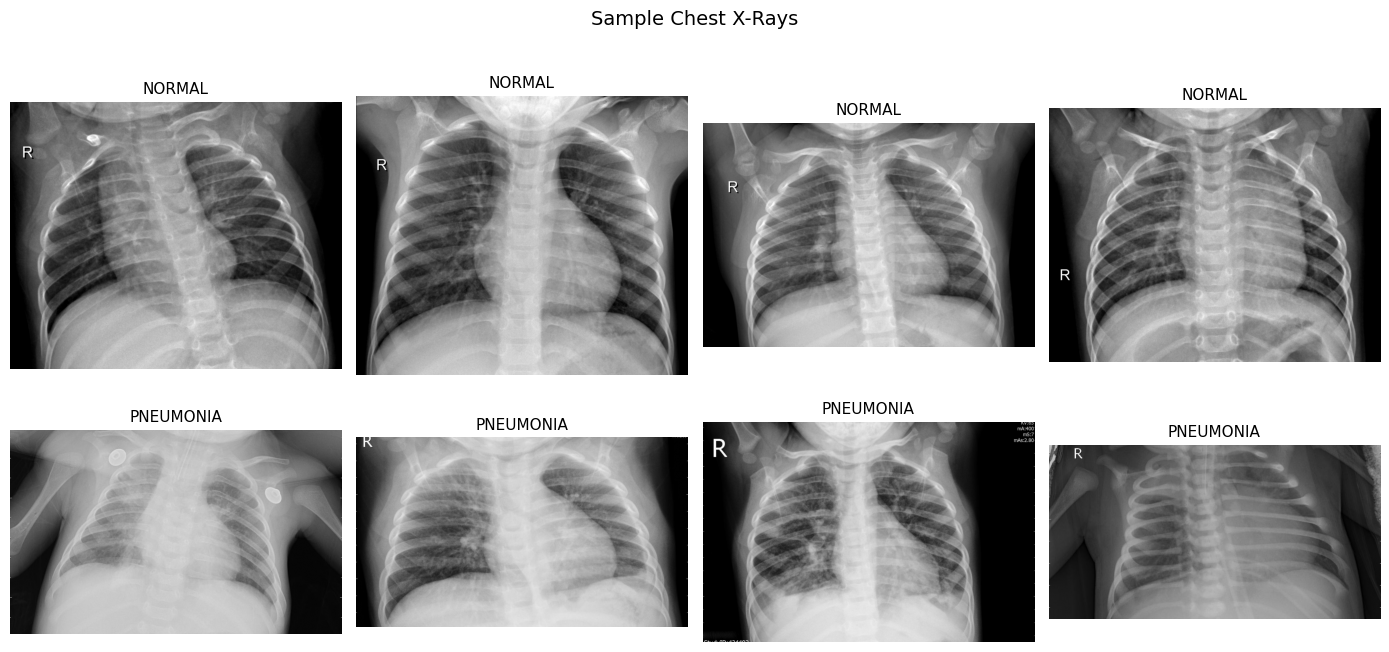

In [12]:
# Preview a sample from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    samples = random.sample(os.listdir(cls_dir), 4)
    for col, fname in enumerate(samples):
        img = plt.imread(os.path.join(cls_dir, fname))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(cls, fontsize=11)
        axes[row, col].axis("off")
plt.suptitle("Sample Chest X-Rays", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Preprocessing & Data Loading

**Choices made:**
- Resize all images to **224 × 224** pixels.
- Normalize pixel values to **[0, 1]**.
- Apply data augmentation on the training set (horizontal flip, rotation ±15°, zoom ±10%) to improve generalization.
- Use a **subset** (~1,000 images per class from the training split) by default to keep CPU wall-clock time manageable.  
  To train on the full dataset, set `SUBSET_PER_CLASS = None` in the cell below.
- Compute **class weights** to mitigate the ~3:1 pneumonia/normal imbalance.

In [13]:
IMG_SIZE        = (224, 224)
BATCH_SIZE      = 32
VAL_SPLIT       = 0.15          # 15 % of training images held out for validation

# Set to None to use the entire training set (much slower on CPU)
SUBSET_PER_CLASS = 1000

In [14]:
def build_subset_dir(src_dir, dest_dir, n_per_class, seed=SEED):
    """Copy a balanced subset of images into a temporary directory tree."""
    import shutil
    if os.path.exists(dest_dir):
        shutil.rmtree(dest_dir)
    rng = random.Random(seed)
    for cls in os.listdir(src_dir):
        cls_src = os.path.join(src_dir, cls)
        if not os.path.isdir(cls_src):
            continue
        cls_dst = os.path.join(dest_dir, cls)
        os.makedirs(cls_dst, exist_ok=True)
        files = os.listdir(cls_src)
        chosen = rng.sample(files, min(n_per_class, len(files)))
        for f in chosen:
            shutil.copy2(os.path.join(cls_src, f), os.path.join(cls_dst, f))
    return dest_dir


if SUBSET_PER_CLASS is not None:
    import tempfile
    tmp_dir = os.path.join(tempfile.gettempdir(), "xray_subset")
    active_train_dir = build_subset_dir(TRAIN_DIR, tmp_dir, SUBSET_PER_CLASS)
    print(f"Using subset: {SUBSET_PER_CLASS} images/class → {active_train_dir}")
    for cls in sorted(os.listdir(active_train_dir)):
        n = len(os.listdir(os.path.join(active_train_dir, cls)))
        print(f"  {cls}: {n}")
else:
    active_train_dir = TRAIN_DIR
    print("Using full training dataset:", active_train_dir)

Using subset: 1000 images/class → C:\Users\Brunden\AppData\Local\Temp\xray_subset
  NORMAL: 1000
  PNEUMONIA: 1000


In [15]:
# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=VAL_SPLIT,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.10,
    width_shift_range=0.05,
    height_shift_range=0.05,
)

# Validation / test generators - no augmentation, only rescaling
val_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=VAL_SPLIT,
)

train_gen = train_datagen.flow_from_directory(
    active_train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    seed=SEED,
    color_mode="rgb",
)

val_gen = val_test_datagen.flow_from_directory(
    active_train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    seed=SEED,
    color_mode="rgb",
    shuffle=False,
)

test_gen = ImageDataGenerator(rescale=1.0 / 255).flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False,
)

print("Class indices:", train_gen.class_indices)   # {NORMAL: 0, PNEUMONIA: 1}

Found 1700 images belonging to 2 classes.
Found 300 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [16]:
# Compute class weights for the training split
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_gen.classes,
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


---
## 4. Baseline CNN Architecture

The model follows a standard **Conv → Pool → Conv → Pool → Conv → Pool → Flatten → Dense** pattern, trained entirely from scratch (no pre-trained weights).

```
Input (224×224×3)
→ Conv2D(32, 3×3, relu)  → MaxPool(2×2)
→ Conv2D(64, 3×3, relu)  → MaxPool(2×2)
→ Conv2D(128, 3×3, relu) → MaxPool(2×2)
→ Flatten
→ Dense(128, relu) → Dropout(0.5)
→ Dense(1, sigmoid)   ← binary output
```

In [17]:
def build_baseline_cnn(input_shape=(224, 224, 3)):
    model = keras.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation="relu", padding="same",
                      input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Classifier head
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ], name="baseline_cnn")
    return model


model = build_baseline_cnn()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.summary()

c:\Users\Brunden\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

---
## 5. Training

Callbacks used:
- **ModelCheckpoint** - saves the weights with the best validation loss.
- **EarlyStopping** - halts training if validation loss does not improve for 3 consecutive epochs (restores best weights automatically).

In [18]:
EPOCHS      = 10
CKPT_PATH   = "best_baseline_cnn.keras"

callbacks = [
    ModelCheckpoint(
        filepath=CKPT_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.6117 - loss: 0.8180
Epoch 1: val_loss improved from None to 0.31889, saving model to best_baseline_cnn.keras

Epoch 1: finished saving model to best_baseline_cnn.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 622ms/step - accuracy: 0.7176 - loss: 0.6010 - val_accuracy: 0.8700 - val_loss: 0.3189
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.8612 - loss: 0.3379
Epoch 2: val_loss improved from 0.31889 to 0.22433, saving model to best_baseline_cnn.keras

Epoch 2: finished saving model to best_baseline_cnn.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 476ms/step - accuracy: 0.8582 - loss: 0.3308 - val_accuracy: 0.9233 - val_loss: 0.2243
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8987 - loss: 0.2807
Epoch 3: val_loss did not improve from 0.22433
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 484ms/step - accuracy: 0.8906 - loss: 0.2835 - val_accuracy: 0.8967 - val_loss: 0.2681
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4

---
## 6. Evaluation & Visualization

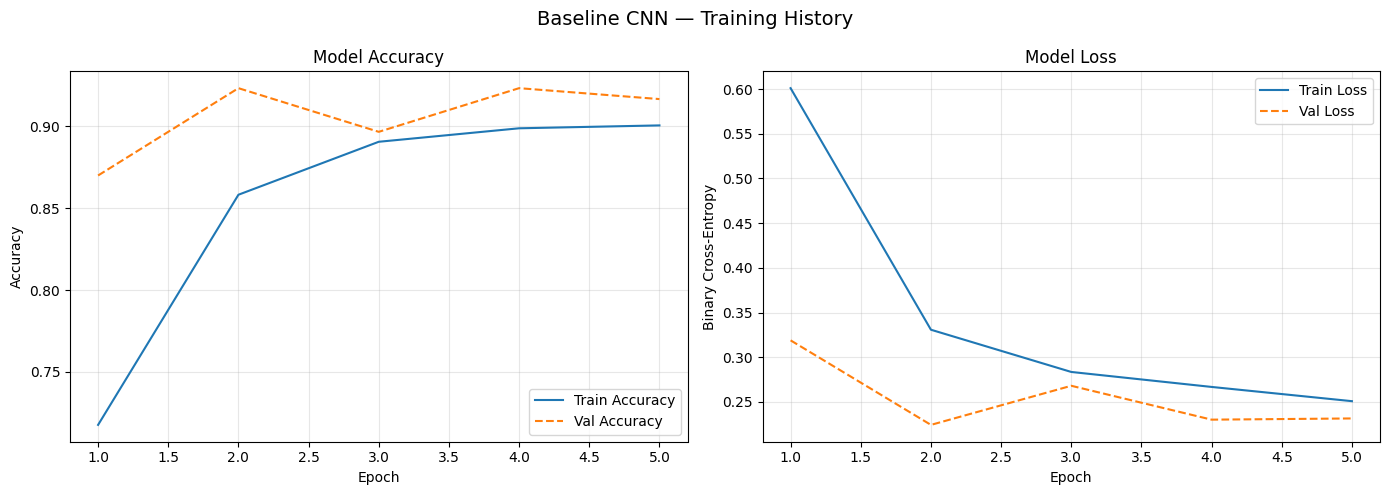

In [19]:
# --- Learning curves ---
hist = history.history
epochs_ran = range(1, len(hist["loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, hist["accuracy"],     label="Train Accuracy")
ax1.plot(epochs_ran, hist["val_accuracy"], label="Val Accuracy", linestyle="--")
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, hist["loss"],     label="Train Loss")
ax2.plot(epochs_ran, hist["val_loss"], label="Val Loss", linestyle="--")
ax2.set_title("Model Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Binary Cross-Entropy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Baseline CNN - Training History", fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# --- Test set evaluation ---
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.1f} %)")

Test Loss     : 0.4724
Test Accuracy : 0.8157  (81.6 %)


In [21]:
# --- Predictions on test set ---
test_gen.reset()
y_prob = model.predict(test_gen, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())   # ['NORMAL', 'PNEUMONIA']

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.88      0.59      0.70       234
   PNEUMONIA       0.79      0.95      0.87       390

    accuracy                           0.82       624
   macro avg       0.84      0.77      0.79       624
weighted avg       0.83      0.82      0.81       624



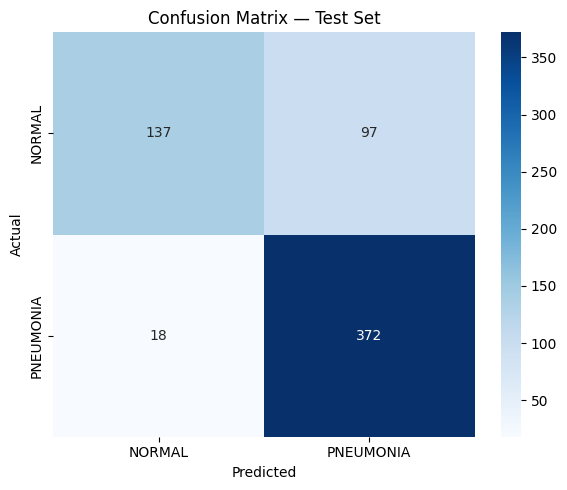

In [22]:
# --- Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

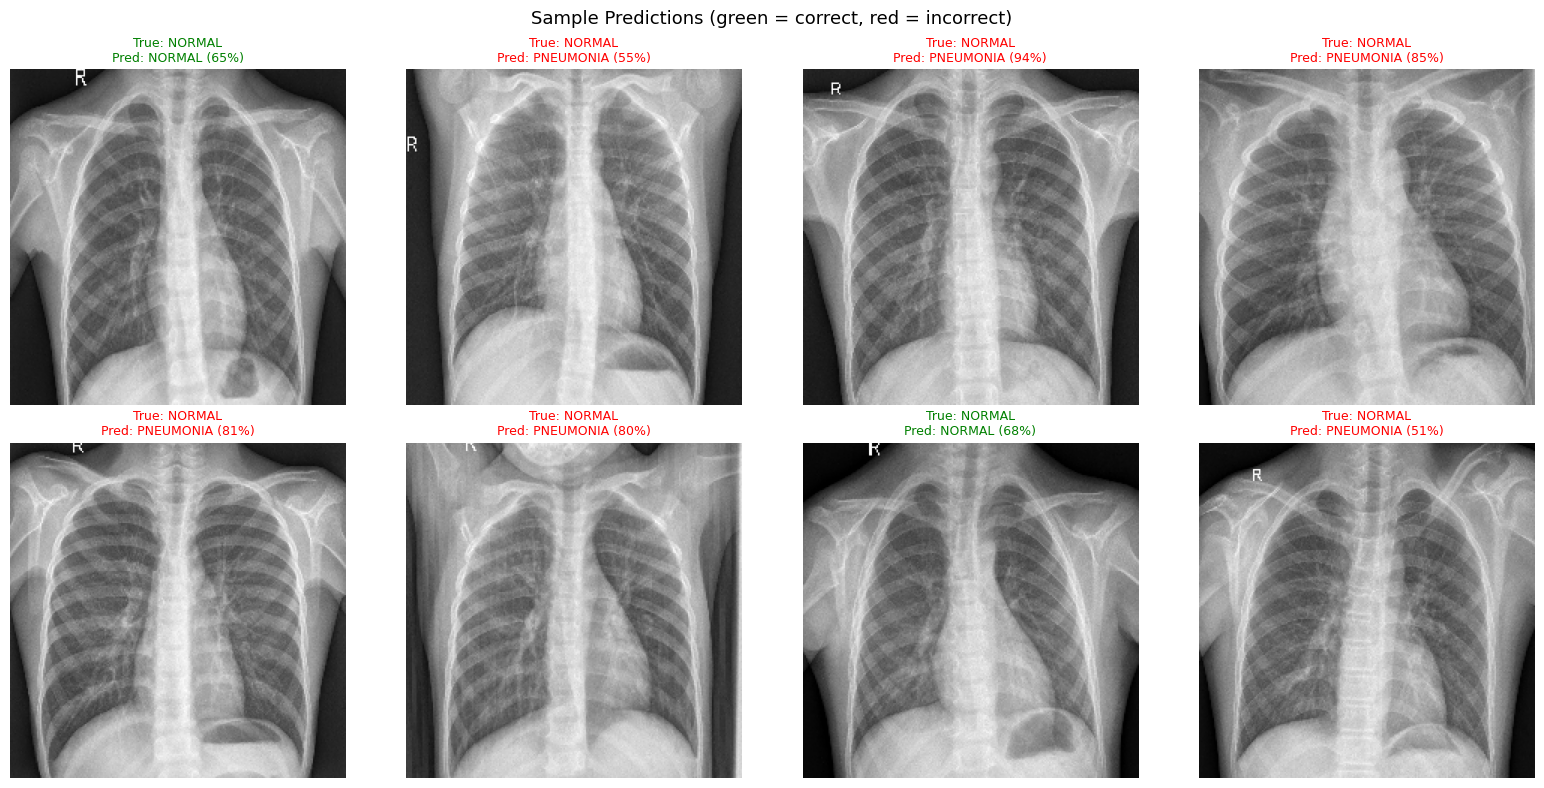

In [23]:
# --- Sample predictions ---
test_gen.reset()
imgs, labels = next(test_gen)
preds = model.predict(imgs, verbose=0).ravel()

n_show = min(8, len(imgs))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i in range(n_show):
    axes[i].imshow(imgs[i])   # already normalized to [0,1], imshow handles it
    true_label = class_names[int(labels[i])]
    pred_label = class_names[int(preds[i] >= 0.5)]
    confidence = preds[i] if preds[i] >= 0.5 else 1 - preds[i]
    color = "green" if true_label == pred_label else "red"
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.0%})",
        color=color,
        fontsize=9,
    )
    axes[i].axis("off")

plt.suptitle("Sample Predictions (green = correct, red = incorrect)", fontsize=13)
plt.tight_layout()
plt.show()